# Punto 1: Costo Uniforme, A* y Beam Search en una cuadrícula

Mapa de `12 × 12`. El `0` es celda libre y el `1` es obstáculo. El inicio está en `(0, 0)` y el objetivo en `(11, 11)`. Los muros dejan un corredor derecho que se ve cerca del objetivo y un rodeo por la izquierda. Cada movimiento cuesta 1.

In [1]:
from heapq import heappush, heappop
from itertools import count
from pathlib import Path
import math

from IPython.display import display
import matplotlib.pyplot as plt

In [2]:
# Matriz que representa el mapa.
mapa = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
]

# Coordenada inicial.
INICIO = (0, 0)

# Coordenada que queremos alcanzar.
OBJETIVO = (11, 11)

# Cada tupla indica cuánto cambia (fila, columna).
# ( 1, 0) -> abajo
# (-1, 0) -> arriba
# ( 0, 1) -> derecha
# ( 0,-1) -> izquierda
MOVIMIENTOS = [
    (1, 0),
    (-1, 0),
    (0, 1),
    (0, -1),
]

# Carpeta donde se guardan las figuras del informe.
CARPETA_IMAGENES = Path("../../results/informed-search/images")
CARPETA_IMAGENES.mkdir(parents=True, exist_ok=True)

In [3]:
def sucesores_mapa(mapa, posicion):
    # Número de filas de la matriz.
    filas = len(mapa)

    # Número de columnas de la matriz.
    columnas = len(mapa[0])

    # Desempaquetamos la posición actual.
    f, c = posicion

    # Aquí guardaremos únicamente movimientos válidos.
    sucesores = []

    # Probamos cada desplazamiento definido en MOVIMIENTOS.
    for df, dc in MOVIMIENTOS:
        # Calculamos la posible nueva fila y columna.
        nf, nc = f + df, c + dc

        # La posición es válida solamente si:
        # 1. La fila queda dentro del mapa.
        # 2. La columna queda dentro del mapa.
        # 3. La celda contiene 0, es decir, no es un obstáculo.
        if (
            0 <= nf < filas
            and 0 <= nc < columnas
            and mapa[nf][nc] == 0
        ):
            sucesores.append((nf, nc))

    return sucesores


def manhattan(a, b):
    # Distancia en una cuadrícula de 4 vecinos.
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

In [4]:
def costo_uniforme_mapa(mapa, inicio, objetivo):
    """
    Expande primero el nodo con menor costo acumulado g(n).
    No usa heurística.
    """
    # El contador rompe empates en la cola de prioridad.
    desempate = count()
    frontera = []
    heappush(frontera, (0, next(desempate), inicio, [inicio]))

    # Guardamos el menor g visto para cada celda.
    mejor_g = {inicio: 0}
    expandidos = 0

    while frontera:
        g, _, nodo, camino = heappop(frontera)

        # Si ya llegamos a este nodo con un g menor, ignoramos esta entrada.
        if g != mejor_g.get(nodo):
            continue

        expandidos += 1

        if nodo == objetivo:
            return {
                "camino": camino,
                "costo": g,
                "expandidos": expandidos,
            }

        for vecino in sucesores_mapa(mapa, nodo):
            nuevo_g = g + 1
            if nuevo_g < mejor_g.get(vecino, math.inf):
                mejor_g[vecino] = nuevo_g
                heappush(
                    frontera,
                    (nuevo_g, next(desempate), vecino, camino + [vecino]),
                )

    return None

In [5]:
def a_estrella_mapa(mapa, inicio, objetivo):
    """
    Expande primero el nodo con menor f(n) = g(n) + h(n).
    La heurística es la distancia Manhattan hasta el objetivo.
    """
    desempate = count()
    frontera = []
    heappush(
        frontera,
        (manhattan(inicio, objetivo), 0, next(desempate), inicio, [inicio]),
    )

    mejor_g = {inicio: 0}
    expandidos = 0

    while frontera:
        f, g, _, nodo, camino = heappop(frontera)

        if g != mejor_g.get(nodo):
            continue

        expandidos += 1

        if nodo == objetivo:
            return {
                "camino": camino,
                "costo": g,
                "expandidos": expandidos,
            }

        for vecino in sucesores_mapa(mapa, nodo):
            nuevo_g = g + 1
            if nuevo_g < mejor_g.get(vecino, math.inf):
                mejor_g[vecino] = nuevo_g
                nuevo_f = nuevo_g + manhattan(vecino, objetivo)
                heappush(
                    frontera,
                    (nuevo_f, nuevo_g, next(desempate), vecino, camino + [vecino]),
                )

    return None

In [6]:
def beam_search_mapa(mapa, inicio, objetivo, beam_width=2):
    """
    En cada nivel conserva solo los k candidatos con menor Manhattan.
    No garantiza optimalidad y puede dejar de encontrar solución.
    """
    haz = [(inicio, [inicio])]
    visitados = {inicio}
    expandidos = 0

    while haz:
        candidatos = []

        for nodo, camino in haz:
            expandidos += 1

            if nodo == objetivo:
                return {
                    "camino": camino,
                    "costo": len(camino) - 1,
                    "expandidos": expandidos,
                    "beam_width": beam_width,
                }

            for vecino in sucesores_mapa(mapa, nodo):
                if vecino not in visitados:
                    visitados.add(vecino)
                    candidatos.append((vecino, camino + [vecino]))

        # Ordenamos por la estimación de lo que falta y recortamos el haz.
        candidatos.sort(key=lambda item: manhattan(item[0], objetivo))
        haz = candidatos[:beam_width]

    return None

In [7]:
resultado_ucs = costo_uniforme_mapa(mapa, INICIO, OBJETIVO)
resultado_astar = a_estrella_mapa(mapa, INICIO, OBJETIVO)

resultados_beam = {}
for k in [1, 2, 4, 8]:
    resultados_beam[k] = beam_search_mapa(mapa, INICIO, OBJETIVO, beam_width=k)

resultado_ucs, resultado_astar, resultados_beam

({'camino': [(0, 0),
   (0, 1),
   (0, 2),
   (0, 3),
   (0, 4),
   (0, 5),
   (0, 6),
   (0, 7),
   (0, 8),
   (0, 9),
   (0, 10),
   (0, 11),
   (1, 11),
   (2, 11),
   (3, 11),
   (4, 11),
   (5, 11),
   (6, 11),
   (7, 11),
   (8, 11),
   (9, 11),
   (10, 11),
   (11, 11)],
  'costo': 22,
  'expandidos': 49},
 {'camino': [(0, 0),
   (0, 1),
   (0, 2),
   (0, 3),
   (0, 4),
   (0, 5),
   (0, 6),
   (0, 7),
   (0, 8),
   (0, 9),
   (0, 10),
   (0, 11),
   (1, 11),
   (2, 11),
   (3, 11),
   (4, 11),
   (5, 11),
   (6, 11),
   (7, 11),
   (8, 11),
   (9, 11),
   (10, 11),
   (11, 11)],
  'costo': 22,
  'expandidos': 36},
 {1: {'camino': [(0, 0),
    (1, 0),
    (2, 0),
    (2, 1),
    (2, 2),
    (2, 3),
    (2, 4),
    (2, 5),
    (2, 6),
    (2, 7),
    (2, 8),
    (2, 9),
    (3, 9),
    (4, 9),
    (4, 8),
    (4, 7),
    (4, 6),
    (4, 5),
    (4, 4),
    (4, 3),
    (4, 2),
    (4, 1),
    (4, 0),
    (5, 0),
    (6, 0),
    (7, 0),
    (8, 0),
    (8, 1),
    (8, 2),
    (8, 3

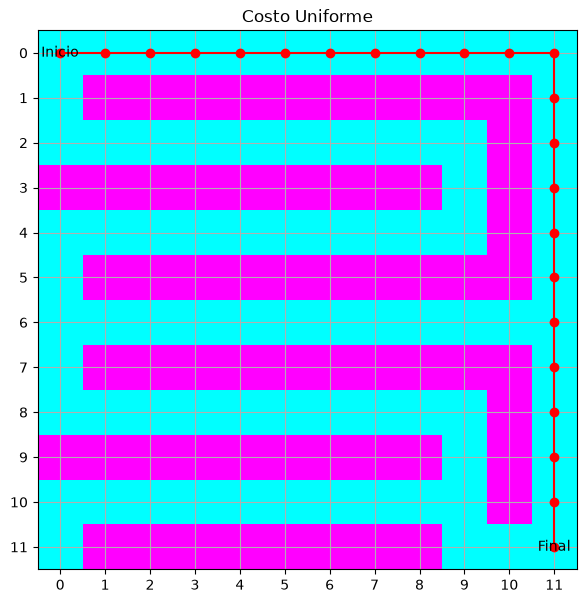

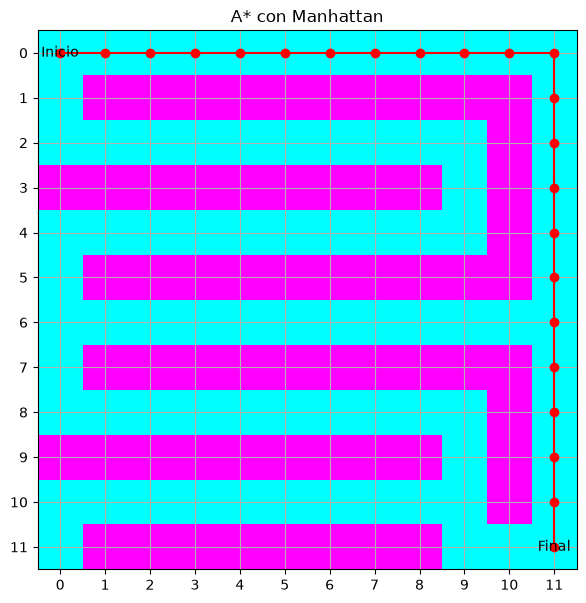

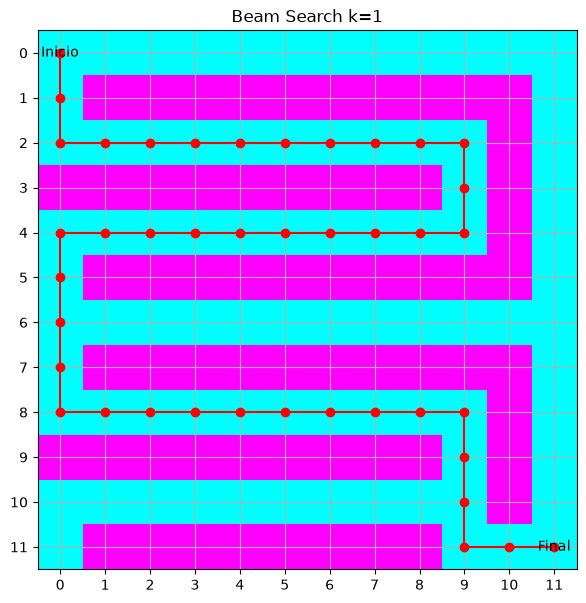

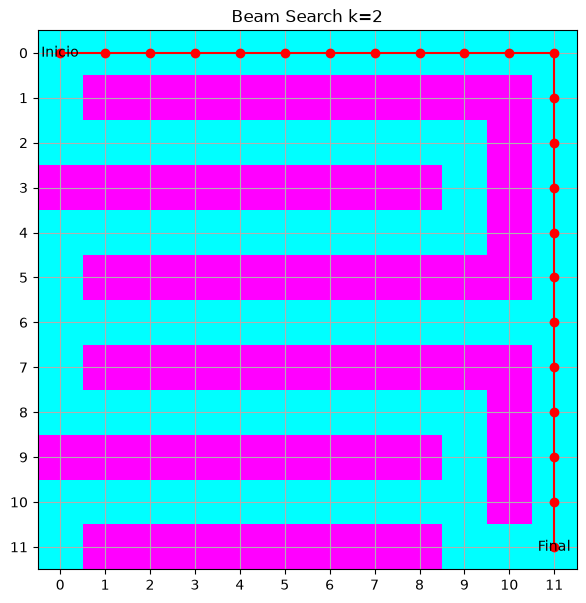

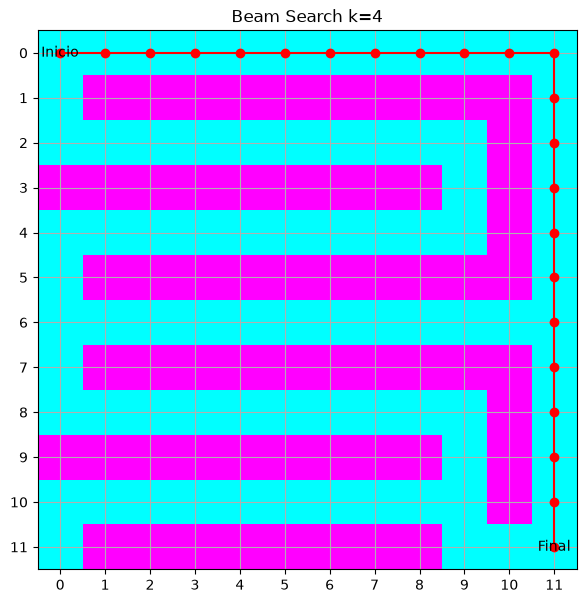

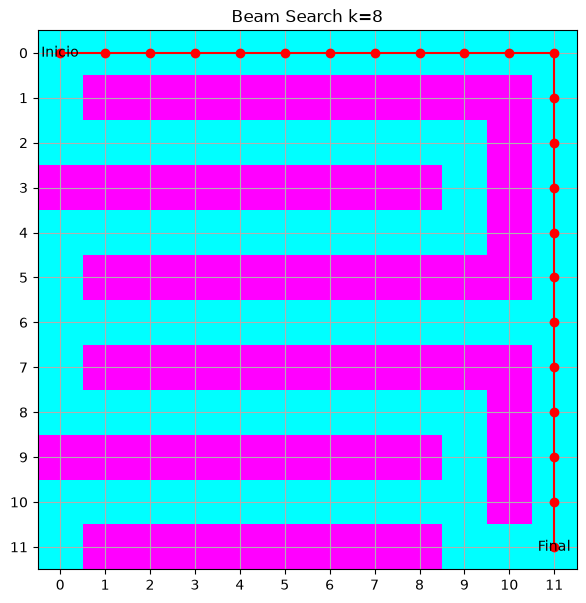

In [8]:
def mostrar_mapa(
    mapa,
    camino=None,
    inicio=None,
    objetivo=None,
    titulo="Mapa",
    archivo=None,
):
    # Creamos la figura donde se dibujará la matriz.
    fig, ax = plt.subplots(figsize=(7, 7))

    # Mostramos los valores 0 y 1 como una imagen.
    ax.imshow(mapa, cmap="cool")

    # Si existe un camino, separamos sus columnas (x) y filas (y).
    if camino:
        xs = [c for f, c in camino]
        ys = [f for f, c in camino]
        ax.plot(xs, ys, c="red", marker="o")

    if inicio:
        ax.text(inicio[1], inicio[0], "Inicio", ha="center", va="center", fontsize=10)
    if objetivo:
        ax.text(objetivo[1], objetivo[0], "Final", ha="center", va="center", fontsize=10)

    ax.set_xticks(range(len(mapa[0])))
    ax.set_yticks(range(len(mapa)))
    ax.set_title(titulo)
    ax.grid(True)

    if archivo:
        fig.savefig(archivo, bbox_inches="tight")

    # display evita plt.show() con el backend Agg.
    display(fig)
    plt.close(fig)


mostrar_mapa(
    mapa,
    resultado_ucs["camino"],
    INICIO,
    OBJETIVO,
    "Costo Uniforme",
    CARPETA_IMAGENES / "1-ucs.png",
)

mostrar_mapa(
    mapa,
    resultado_astar["camino"],
    INICIO,
    OBJETIVO,
    "A* con Manhattan",
    CARPETA_IMAGENES / "1-astar.png",
)

for k, resultado in resultados_beam.items():
    camino = None if resultado is None else resultado["camino"]
    titulo = f"Beam Search k={k}"
    if resultado is None:
        titulo += " (sin solución)"
    mostrar_mapa(
        mapa,
        camino,
        INICIO,
        OBJETIVO,
        titulo,
        CARPETA_IMAGENES / f"1-beam-k{k}.png",
    )

In [9]:
def resumen(resultado):
    if resultado is None:
        return {"costo": None, "expandidos": None, "solucion": False}
    return {
        "costo": resultado["costo"],
        "expandidos": resultado["expandidos"],
        "solucion": True,
    }


comparacion = {
    "Costo Uniforme": resumen(resultado_ucs),
    "A*": resumen(resultado_astar),
}
for k, resultado in resultados_beam.items():
    comparacion[f"Beam Search k={k}"] = resumen(resultado)

comparacion

{'Costo Uniforme': {'costo': 22, 'expandidos': 49, 'solucion': True},
 'A*': {'costo': 22, 'expandidos': 36, 'solucion': True},
 'Beam Search k=1': {'costo': 40, 'expandidos': 41, 'solucion': True},
 'Beam Search k=2': {'costo': 22, 'expandidos': 44, 'solucion': True},
 'Beam Search k=4': {'costo': 22, 'expandidos': 48, 'solucion': True},
 'Beam Search k=8': {'costo': 22, 'expandidos': 48, 'solucion': True}}